# e13 campaign results — 0.48 → 0.86 without a textual edge list

**2026-07-21/22.** One session, five experiments, every step a single-flag A/B.
Full decision log: `2026-07-21 e13_nav_pe_setup.md`; gate diagnostic:
`2026-07-21 e13b_decode_style_diagnostic.ipynb`. W&B tags: `e13_nav_pe`,
`e13c_decode_consistent`, `e13d_nav_decode`, `e13e_layer_scope`,
`e13f_alpha_khops`.

| step | intervention | result |
|---|---|---|
| e11 (ref) | leak-free RPE mask, prompt-only wiring | 0.48 |
| e13 | navigator Ψ (GT+AGT), prompt-only wiring | 0.58 |
| e13c | **decode-consistent injection** (edge-detector Ψ) | **0.73** |
| e13d | decode-consistent × navigator GT | **0.79** |
| e13f | mask_alpha=0.0 (pure learned sim on legal edges) | **0.86** |
| — | with-edges reference band | 0.87–0.95 |

The core mechanism (e13c/e13d): train with answer-side mask wiring that is
**exactly reproducible at decode** (mentions act as keys once complete, as
queries at the position where their identity becomes knowable), and extend the
mask to generated mentions during generation (`MaskDecodeInjector`). The model
then reads each hop's legal neighborhood at the moment it commits to the next
hop — hallucination drops 0.17 → 0.035.


In [2]:
import wandb
import pandas as pd

api = wandb.Api()
TAGS = ["e13_nav_pe", "e13c_decode_consistent", "e13d_nav_decode", "e13e_layer_scope",
        "e13f_alpha_khops"]
rows = []
for tag in TAGS:
    for r in api.runs("alelab/GREP-PRISM", filters={"tags": tag}):
        s = r.summary
        rows.append({"run": r.name, "tag": tag, "acc": s.get("eval/accuracy"),
                     "halluc": s.get("eval/hallucination_rate"),
                     "hop_opt": s.get("eval/path_optimality_rate")})
df = pd.DataFrame(rows).drop_duplicates("run").sort_values("acc", ascending=False)
REFS = pd.DataFrame([
    {"run": "e11_integ_rpe_promptonly (ref)", "tag": "e11", "acc": 0.48, "halluc": None, "hop_opt": None},
    {"run": "e11_gmask_promptonly (ref)", "tag": "e11", "acc": 0.39, "halluc": None, "hop_opt": None},
    {"run": "with-edges band (ref)", "tag": "ref", "acc": 0.95, "halluc": None, "hop_opt": None},
])
df = pd.concat([df, REFS], ignore_index=True).sort_values("acc", ascending=False)
print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jporras/.netrc.


                           run                    tag   acc  halluc  hop_opt
         with-edges band (ref)                    ref 0.950     NaN      NaN
                  e13f_alpha00       e13f_alpha_khops 0.860   0.013    1.515
                  e13f_alpha09       e13f_alpha_khops 0.840   0.012    1.600
                e13d_gt_decode        e13d_nav_decode 0.790   0.035    1.385
               e13d_agt_decode        e13d_nav_decode 0.790   0.038    1.421
                  e13f_alpha03       e13f_alpha_khops 0.790   0.037    1.414
               e13c_rpe_decode e13c_decode_consistent 0.730   0.060    1.451
              e13e_rpe_tophalf       e13e_layer_scope 0.630   0.065    1.450
             e13c_gmask_decode e13c_decode_consistent 0.610   0.088    1.355
                e13_agt_joint3             e13_nav_pe 0.580   0.128    1.310
                e13_agt_joint2             e13_nav_pe 0.480   0.173    1.111
e11_integ_rpe_promptonly (ref)                    e11 0.480     NaN      NaN

/tmp/ipykernel_3969121/1785704884.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, REFS], ignore_index=True).sort_values("acc", ascending=False)


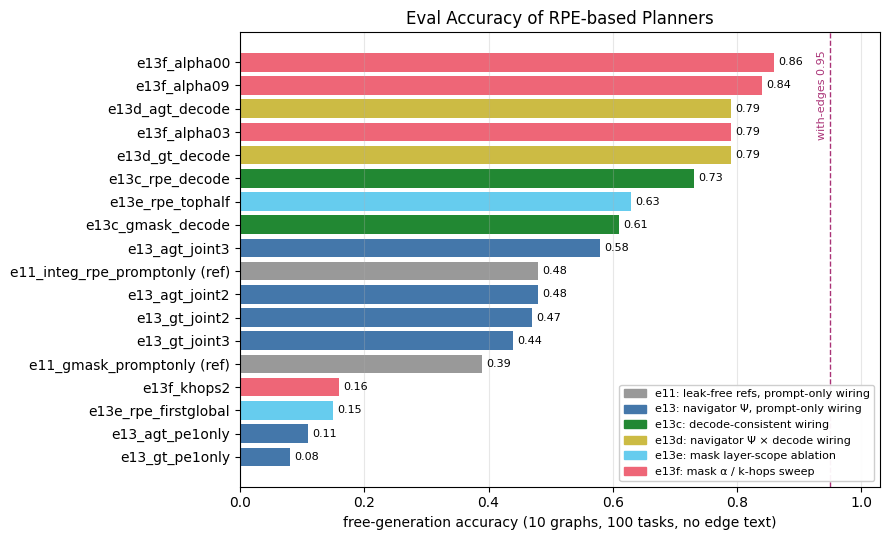

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

d = df[df.tag != "ref"].dropna(subset=["acc"]).sort_values("acc")
colors = {"e11": "#999999", "e13_nav_pe": "#4477AA", "e13c_decode_consistent": "#228833",
          "e13d_nav_decode": "#CCBB44", "e13e_layer_scope": "#66CCEE",
          "e13f_alpha_khops": "#EE6677"}
tag_labels = {"e11": "e11: leak-free refs, prompt-only wiring",
              "e13_nav_pe": "e13: navigator \u03a8, prompt-only wiring",
              "e13c_decode_consistent": "e13c: decode-consistent wiring",
              "e13d_nav_decode": "e13d: navigator \u03a8 \u00d7 decode wiring",
              "e13e_layer_scope": "e13e: mask layer-scope ablation",
              "e13f_alpha_khops": "e13f: mask \u03b1 / k-hops sweep"}
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(d.run, d.acc, color=[colors[t] for t in d.tag])
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.axvline(0.95, color="#AA3377", ls="--", lw=1)
ax.text(0.945, len(d) - 0.5, "with-edges 0.95", rotation=90, fontsize=8,
        color="#AA3377", ha="right", va="top")
handles = [Patch(color=colors[t], label=tag_labels[t])
           for t in tag_labels if t in set(d.tag)]
ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.95)
ax.set_xlim(0, 1.03)
ax.set_xlabel("free-generation accuracy (10 graphs, 100 tasks, no edge text)")
ax.set_title("Eval Accuracy of RPE-based Planners")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(); plt.show()


## Notes on the ladder

- **Ψ content matters less than wiring**: decode-consistent wiring moved
  +0.25/+0.22 (learnable/param-free); swapping edge-detector Ψ for the
  navigation-pretrained GT added +0.06 on top. GT-only ≡ GT+AGT under decode
  wiring (0.79 both) — the AGT's prompt-only advantage (+0.14) was compensating
  for the weaker channel, not adding unique content.
- **Layer scope**: the mask needs all 10 global layers (0.73) — deeper-5 only
  = 0.63, first-global-only = 0.15. The channel is distributed; no compression.
- **Diagnostic** (cell below): the decode-consistent checkpoint reads
  0.861/0.49 nats per decision through its native, generation-legal wiring —
  the leak circuit's old level, now legitimately. Per-decision gap to text
  edges: ~6 points / 0.2 nats.
- **α sweep (e13f)**: edge values are `α + (1−α)·cos(ΨΨᵀ)` on legal pairs,
  −inf elsewhere. Finals: α=0.0 → **0.86**, α=0.3 → 0.79, α=0.7 → 0.79 (ref),
  α=0.9 → 0.84. Non-monotone; spread ≈ 1.5 s.e. — flat within noise, though
  hallucination separates cleanly (~0.012 extremes vs ~0.036 mid-α).
- **k_hops=2 collapse (0.16, halluc 0.51)**: hard-allowing distance-2 pairs
  legalizes exactly the dominant distance-2-skip failure mode. The 1-hop hard
  block is the load-bearing signal; widening/softening it destroys the channel
  (settles the full-N×N soft-bias proposal negatively).


In [4]:
d = json.load(open("../outputs/e13c_analysis/injection_diag_decode.json"))
print("decision-token diagnostic, e13c_rpe_decode checkpoint (n=519):")
for c in ["no_injection", "prompt_only", "decode_style", "decode_trail", "train_style"]:
    m = d["conditions"][c]["decision"]
    print(f"  {c:14s} acc={m['acc']:.4f}  nll={m['mean_nll']:.3f}")
print("  (with-edges benchmark reference: 0.921 / 0.29 — see e13b notebook)")


NameError: name 'json' is not defined

In [ ]:
import json, glob, collections
import networkx as nx
from prism.data import utils as prism_utils

ev = json.load(open("../outputs/e13c_analysis/e13d_gt_decode_final_eval.json"))
graphs = {}
for f in glob.glob("../data/revised/gen/nav100_n30_gemma_data/split/test_graphs/*.json"):
    stem = f.split("/")[-1].replace(".json", "")
    payload = json.load(open(f))
    G, _ = prism_utils.safe_parse_graph(payload["graph"] if "graph" in payload else payload)
    graphs[stem] = G

fails = [s for s in ev["samples"] if not s["correct"]]
tax = collections.Counter()
dist_hist = collections.Counter()
for s in fails:
    pm = s.get("path_metrics") or {}
    if pm.get("full_path_valid"):
        tax["valid_path_wrong_criterion"] += 1
    elif pm.get("edge_validity_rate", 1) < 1:
        tax["hallucinated_edge_in_route"] += 1
    else:
        tax["other"] += 1
    G = graphs.get(s["graph_name"])
    for a, b in zip(pm.get("parsed_nodes") or [], (pm.get("parsed_nodes") or [])[1:]):
        if G is not None and a in G and b in G and not G.has_edge(a, b):
            try: dist_hist[nx.shortest_path_length(G, a, b)] += 1
            except nx.NetworkXNoPath: dist_hist["inf"] += 1

by_kind = collections.defaultdict(lambda: [0, 0])
for s in ev["samples"]:
    wp = "waypoint/avoid" if ("passing through" in str(s["task"]) or "avoid" in str(s["task"]).lower()) else "plain"
    by_kind[wp][0] += s["correct"]; by_kind[wp][1] += 1
lens = collections.defaultdict(lambda: [0, 0])
for s in ev["samples"]:
    n = (s.get("path_metrics") or {}).get("num_parsed") or 0
    b = "2-3" if n <= 3 else ("4-5" if n <= 5 else "6+")
    lens[b][0] += s["correct"]; lens[b][1] += 1

print(f"failures: {len(fails)}/100   taxonomy: {dict(tax)}")
print(f"hallucinated-edge true distances: {dict(dist_hist)}")
print("acc by task type:", {k: f"{a}/{n}={a/n:.2f}" for k, (a, n) in by_kind.items()})
print("acc by route length:", {k: f"{a}/{n}={a/n:.2f}" for k, (a, n) in sorted(lens.items())})


failures: 21/100   taxonomy: {'hallucinated_edge_in_route': 14, 'valid_path_wrong_criterion': 7}
hallucinated-edge true distances: {3: 3, 2: 10, 4: 2}
acc by task type: {'plain': '50/60=0.83', 'waypoint/avoid': '29/40=0.72'}
acc by route length: {'2-3': '24/28=0.86', '4-5': '44/53=0.83', '6+': '11/19=0.58'}


## Failure profile of e13d_gt_decode (0.79; predates the 0.86 e13f arm)

The residual is narrow: hallucinated single hops inside otherwise-valid routes,
overwhelmingly **distance-2 near-misses** (skipping one intermediate node), plus
a long-route penalty (6+-node routes at 0.58 vs 0.86 short). Formatting,
nonexistent-node, and runtime failures are extinct. This points at two levers:
**legal-next-hop constrained decoding** (mechanically eliminates non-edge hops;
the injector already tracks the current node at the right decode steps) and
long-horizon / waypoint supervision.

Also measured (see conversation log 2026-07-22): the nav-pretrained GT's cosine
sim carries graded proximity (Spearman(sim, −SPD) ≈ +0.32, monotone to ~4 hops,
noisy tail). The e13f `mask_k_hops=2` arm tested the widen-the-mask family and
collapsed (0.16) — recorded as a dead end.

## Caveats

Single seed per arm; n=100 tasks (±0.05 s.e.); all numbers 31B, n30 graphs.
The 0.86-vs-0.79 (+0.07) and all α-sweep deltas are within ~1.5 s.e. The
0.48→0.73/0.79/0.86 jumps are 4–8 s.e. Replication seeds for the top recipe
(α=0.0 nav-GT decode-consistent) are the next queued run.
